# Sklearn Multilabel Baselines

Notebook 02 trained **independent** XGBoost classifiers per label (Binary Relevance).  
This notebook explores sklearn's built-in multilabel strategies that **capture label dependencies**.

| Method | Label dependencies? | Model family | Key idea |
|--------|-------------------|--------------|----------|
| `OneVsRestClassifier(LogisticRegression)` | No | Linear | Simplest possible baseline |
| `ClassifierChain(LogisticRegression)` | **Yes** | Linear | Each label sees prior label predictions as features |
| `ClassifierChain(RandomForest)` | **Yes** | Tree ensemble | Nonlinear + label chaining |
| `MLPClassifier` (native multilabel) | **Implicit** | Neural net | Shared hidden layers, sigmoid outputs |

In [13]:
import numpy as np
import pandas as pd
import pickle
import time
from pathlib import Path

from sklearn.multioutput import ClassifierChain
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    average_precision_score, hamming_loss,
    precision_recall_curve, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

%matplotlib inline

## 1. Load Data

In [14]:
from sklearn.model_selection import train_test_split

DATA_DIR = Path('../chronological_filtered_prepared_data')

X_train_full = np.load(DATA_DIR / 'X_train.npy')
X_test       = np.load(DATA_DIR / 'X_test.npy')
y_train_full = np.load(DATA_DIR / 'y_train.npy')
y_test       = np.load(DATA_DIR / 'y_test.npy')

with open(DATA_DIR / 'metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

feature_names    = metadata['feature_names']
all_target_names = metadata['target_names']

# --- Drop labels with < 100 positive training samples ---
MIN_POS = 100
pos_counts = y_train_full.sum(axis=0)
keep_mask  = pos_counts >= MIN_POS
n_dropped  = (~keep_mask).sum()

target_names = [n for n, k in zip(all_target_names, keep_mask) if k]
y_train_full = y_train_full[:, keep_mask]
y_test       = y_test[:, keep_mask]

print(f'Dropped {n_dropped} labels with < {MIN_POS} train positives')
print(f'Kept {len(target_names)} labels: {target_names}\n')

# --- Train / Val split (90/10, chronological order preserved) ---
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.1, random_state=42, shuffle=False   # keep temporal order
)

print(f'Train : {X_train.shape[0]:,} x {X_train.shape[1]}')
print(f'Val   : {X_val.shape[0]:,}  x {X_val.shape[1]}')
print(f'Test  : {X_test.shape[0]:,}  x {X_test.shape[1]}')
print(f'Labels: {len(target_names)}')
print(f'Split : {metadata.get("split_type", "unknown")}')

Dropped 5 labels with < 100 train positives
Kept 21 labels: ['Avalanche', 'Blizzard', 'Cold/Wind Chill', 'Debris Flow', 'Dust Storm', 'Excessive Heat', 'Extreme Cold/Wind Chill', 'Flash Flood', 'Flood', 'Hail', 'Heat', 'Heavy Snow', 'Ice Storm', 'Lightning', 'Marine Hail', 'Marine Thunderstorm Wind', 'Thunderstorm Wind', 'Tornado', 'Waterspout', 'Wildfire', 'Winter Weather']

Train : 118,534 x 146
Val   : 13,171  x 146
Test  : 32,927  x 146
Labels: 21
Split : chronological


In [15]:
# Standardise features (important for LogReg and MLP, harmless for RF)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print('Scaled — mean ~0, std ~1')
print(f'  Train mean range: [{X_train_s.mean(axis=0).min():.3f}, {X_train_s.mean(axis=0).max():.3f}]')
print(f'  Train std  range: [{X_train_s.std(axis=0).min():.3f}, {X_train_s.std(axis=0).max():.3f}]')

Scaled — mean ~0, std ~1
  Train mean range: [-0.000, 0.000]
  Train std  range: [0.000, 1.000]


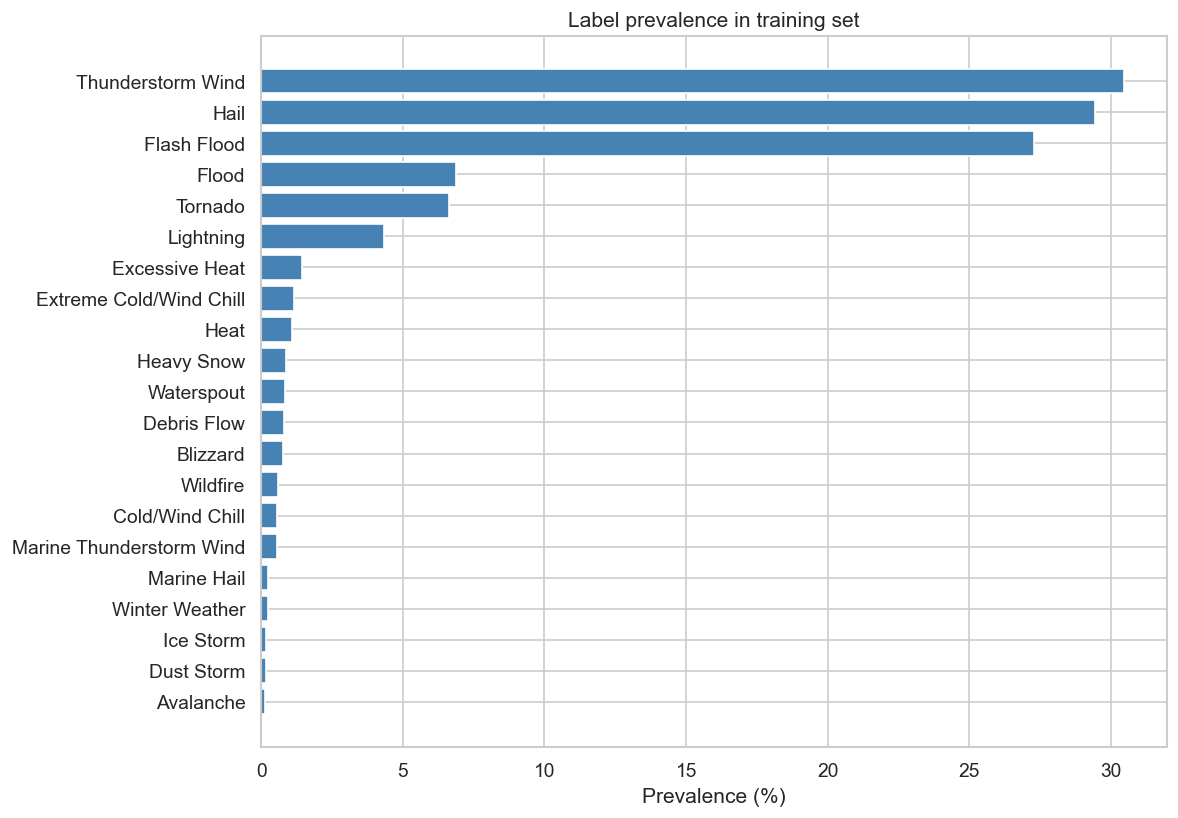

In [16]:
# Quick look at label prevalence
prevalence = y_train.mean(axis=0)
prev_df = pd.DataFrame({'label': target_names, 'train_prev': prevalence}).sort_values('train_prev', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(prev_df['label'], prev_df['train_prev'] * 100, color='steelblue')
ax.set_xlabel('Prevalence (%)')
ax.set_title('Label prevalence in training set')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 2. Shared Evaluation Helpers

In [17]:
def evaluate(name, y_true, y_pred, y_prob=None):
    """Compute standard multilabel metrics and return a summary dict."""
    res = {
        'model': name,
        'f1_macro':      f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'f1_micro':      f1_score(y_true, y_pred, average='micro',    zero_division=0),
        'f1_weighted':   f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro':    recall_score(y_true, y_pred, average='macro',    zero_division=0),
        'hamming_loss':    hamming_loss(y_true, y_pred),
        'subset_accuracy': (y_true == y_pred).all(axis=1).mean(),
    }
    print(f'--- {name} ---')
    for k, v in res.items():
        if k != 'model':
            print(f'  {k:20s} {v:.4f}')
    return res


def per_label_f1(y_true, y_pred, target_names):
    """Return a DataFrame of per-label F1/precision/recall."""
    rows = []
    for i, lbl in enumerate(target_names):
        sup = int(y_true[:, i].sum())
        rows.append({
            'label': lbl,
            'support': sup,
            'f1':        f1_score(y_true[:, i], y_pred[:, i], zero_division=0),
            'precision': precision_score(y_true[:, i], y_pred[:, i], zero_division=0),
            'recall':    recall_score(y_true[:, i], y_pred[:, i], zero_division=0),
        })
    return pd.DataFrame(rows)


# We'll collect all results here
all_results = []
all_preds   = {}  # name -> y_pred

## 3. Hyperparameter Tuning on Validation Set

Before training final models, search over a small grid for each baseline.  
Pick the configuration that maximises **macro F1** on the **validation set**.

In [ ]:
from itertools import product as iter_product

def val_macro_f1(model, X_tr, y_tr, X_v, y_v):
    """Train model, predict on val, return macro F1."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_v)
    return f1_score(y_v, y_pred, average='macro', zero_division=0)

# ── 1. OVR Logistic Regression ──────────────────────────────────
print('=' * 60)
print('Tuning OneVsRest(LogisticRegression) ...')
print('=' * 60)

C_values = [0.01, 0.1, 1.0, 10.0]
best_ovr_score, best_C = -1, 1.0
for C in C_values:
    model = OneVsRestClassifier(
        LogisticRegression(class_weight='balanced', max_iter=1000,
                           solver='saga', C=C, random_state=42, n_jobs=-1),
        n_jobs=-1
    )
    score = val_macro_f1(model, X_train_s, y_train, X_val_s, y_val)
    print(f'  C={C:6.2f}  → val F1_macro = {score:.4f}')
    if score > best_ovr_score:
        best_ovr_score = score
        best_C = C

print(f'\n  ✓ Best OVR-LogReg: C={best_C}, val F1_macro={best_ovr_score:.4f}')

# ── 2. Classifier Chain (Random Forest) ─────────────────────────
print('\n' + '=' * 60)
print('Tuning ClassifierChain(RandomForest) ...')
print('=' * 60)

n_est_values = [50, 100, 200]
depth_values = [5, 10, 20]
best_rf_score, best_rf_params = -1, {'n_estimators': 100, 'max_depth': 10}
for n_est, depth in iter_product(n_est_values, depth_values):
    chains = []
    for seed in [0, 1, 2]:
        chain = ClassifierChain(
            RandomForestClassifier(
                n_estimators=n_est, max_depth=depth,
                class_weight='balanced_subsample',
                random_state=42, n_jobs=-1),
            order='random', random_state=seed)
        chain.fit(X_train_s, y_train)
        chains.append(chain)
    y_prob_v = np.mean([c.predict_proba(X_val_s) for c in chains], axis=0)
    y_pred_v = (y_prob_v >= 0.5).astype(int)
    score = f1_score(y_val, y_pred_v, average='macro', zero_division=0)
    print(f'  n_est={n_est:3d}, depth={depth:2d}  → val F1_macro = {score:.4f}')
    if score > best_rf_score:
        best_rf_score  = score
        best_rf_params = {'n_estimators': n_est, 'max_depth': depth}

print(f'\n  ✓ Best Chain-RF: {best_rf_params}, val F1_macro={best_rf_score:.4f}')

# ── 3. MLP Neural Network ───────────────────────────────────────
print('\n' + '=' * 60)
print('Tuning MLPClassifier ...')
print('=' * 60)

arch_values = [(128, 64), (256, 128), (256, 128, 64)]
lr_values   = [1e-3, 5e-4]
best_mlp_score, best_mlp_params = -1, {'arch': (256, 128), 'lr': 1e-3}
for arch, lr in iter_product(arch_values, lr_values):
    model = MLPClassifier(
        hidden_layer_sizes=arch, activation='relu', solver='adam',
        learning_rate_init=lr, max_iter=100, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=10,
        batch_size=512, random_state=42, verbose=False)
    score = val_macro_f1(model, X_train_s, y_train, X_val_s, y_val)
    print(f'  arch={str(arch):20s}  lr={lr:.0e}  → val F1_macro = {score:.4f}')
    if score > best_mlp_score:
        best_mlp_score  = score
        best_mlp_params = {'arch': arch, 'lr': lr}

print(f'\n  ✓ Best MLP: {best_mlp_params}, val F1_macro={best_mlp_score:.4f}')

print('\n' + '=' * 60)
print('Hyperparameter Summary')
print('=' * 60)
print(f'  OVR LogReg : C = {best_C}')
print(f'  Chain-RF   : {best_rf_params}')
print(f'  MLP        : {best_mlp_params}')
print(f'  Chain-LR   : uses same C = {best_C} from OVR tuning')

Tuning OneVsRest(LogisticRegression) ...


/Users/shikhabhat/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/shikhabhat/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/shikhabhat/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/shikhabhat/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/shikhabhat/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/shikhabh

  C=  0.01  → val F1_macro = 0.5524


## 4. Train Final Models with Best Hyperparameters

### Baseline 1 — OneVsRest Logistic Regression
Uses `class_weight='balanced'` and the best `C` from validation tuning.

In [ ]:
print(f'Training OneVsRest(LogisticRegression) with C={best_C} ...')
t0 = time.time()

ovr_lr = OneVsRestClassifier(
    LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        solver='saga',
        C=best_C,
        random_state=42,
        n_jobs=-1
    ),
    n_jobs=-1
)
ovr_lr.fit(X_train_s, y_train)
elapsed = time.time() - t0

y_pred_ovr     = ovr_lr.predict(X_test_s)
y_prob_ovr     = ovr_lr.predict_proba(X_test_s)
y_prob_ovr_val = ovr_lr.predict_proba(X_val_s)

print(f'Done in {elapsed:.1f}s\n')
res = evaluate('OVR-LogReg', y_test, y_pred_ovr)
all_results.append(res)
all_preds['OVR-LogReg'] = y_pred_ovr

### Baseline 2 — Classifier Chain (Logistic Regression)

Labels are ordered in a chain; each classifier sees prior label predictions as features.  
Uses the same best `C` from OVR tuning. Ensemble of 3 chains with different orderings.

In [ ]:
print(f'Training ClassifierChain(LogisticRegression, C={best_C}) x 3 orderings ...')
t0 = time.time()

chains_lr = []
for seed in [0, 1, 2]:
    chain = ClassifierChain(
        LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            solver='saga',
            C=best_C,
            random_state=42,
            n_jobs=-1
        ),
        order='random',
        random_state=seed
    )
    chain.fit(X_train_s, y_train)
    chains_lr.append(chain)
    print(f'  Chain {seed} done — order: {chain.order_[:5]}...')

elapsed = time.time() - t0
print(f'All chains done in {elapsed:.1f}s\n')

# Ensemble: average predicted probabilities, then threshold
y_prob_chain_lr     = np.mean([c.predict_proba(X_test_s) for c in chains_lr], axis=0)
y_prob_chain_lr_val = np.mean([c.predict_proba(X_val_s)  for c in chains_lr], axis=0)
y_pred_chain_lr     = (y_prob_chain_lr >= 0.5).astype(int)

res = evaluate('Chain-LogReg (x3)', y_test, y_pred_chain_lr)
all_results.append(res)
all_preds['Chain-LogReg (x3)'] = y_pred_chain_lr

### Baseline 3 — Classifier Chain (Random Forest)
Same chaining idea, but with a nonlinear base estimator.  
Uses best `n_estimators` and `max_depth` from validation tuning.

In [ ]:
print(f'Training ClassifierChain(RandomForest, {best_rf_params}) x 3 orderings ...')
t0 = time.time()

chains_rf = []
for seed in [0, 1, 2]:
    chain = ClassifierChain(
        RandomForestClassifier(
            n_estimators=best_rf_params['n_estimators'],
            max_depth=best_rf_params['max_depth'],
            class_weight='balanced_subsample',
            random_state=42,
            n_jobs=-1
        ),
        order='random',
        random_state=seed
    )
    chain.fit(X_train_s, y_train)
    chains_rf.append(chain)
    print(f'  Chain {seed} done ({time.time()-t0:.0f}s elapsed)')

elapsed = time.time() - t0
print(f'\nAll chains done in {elapsed:.1f}s\n')

y_prob_chain_rf     = np.mean([c.predict_proba(X_test_s) for c in chains_rf], axis=0)
y_prob_chain_rf_val = np.mean([c.predict_proba(X_val_s)  for c in chains_rf], axis=0)
y_pred_chain_rf     = (y_prob_chain_rf >= 0.5).astype(int)

res = evaluate('Chain-RF (x3)', y_test, y_pred_chain_rf)
all_results.append(res)
all_preds['Chain-RF (x3)'] = y_pred_chain_rf

### Baseline 4 — MLP Neural Network

sklearn's `MLPClassifier` natively supports multilabel with sigmoid outputs.  
Uses the best architecture and learning rate from validation tuning.

In [ ]:
print(f'Training MLPClassifier with {best_mlp_params} ...')
t0 = time.time()

mlp = MLPClassifier(
    hidden_layer_sizes=best_mlp_params['arch'],
    activation='relu',
    solver='adam',
    learning_rate_init=best_mlp_params['lr'],
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    batch_size=512,
    random_state=42,
    verbose=True
)
mlp.fit(X_train_s, y_train)
elapsed = time.time() - t0

y_pred_mlp     = mlp.predict(X_test_s)
y_prob_mlp     = mlp.predict_proba(X_test_s)
y_prob_mlp_val = mlp.predict_proba(X_val_s)

print(f'\nDone in {elapsed:.1f}s  (stopped at iteration {mlp.n_iter_})\n')
mlp_label = f'MLP {best_mlp_params["arch"]}'
res = evaluate(mlp_label, y_test, y_pred_mlp)
all_results.append(res)
all_preds[mlp_label] = y_pred_mlp

In [ ]:
# --- MLP training curve ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mlp.loss_curve_, label='train loss')
if hasattr(mlp, 'validation_scores_') and mlp.validation_scores_ is not None:
    ax2 = ax.twinx()
    ax2.plot(mlp.validation_scores_, color='coral', label='val score')
    ax2.set_ylabel('Validation score', color='coral')
    ax2.legend(loc='center right')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('MLP Training Curve')
ax.legend(loc='center left')
plt.tight_layout()
plt.show()

## 5. Per-label Threshold Tuning
All models above use default 0.5 threshold.  
Tune per-label thresholds on the **validation set**, then evaluate on the **test set**.

In [ ]:
def tune_thresholds(y_true, y_prob, target_names):
    """Find per-label threshold that maximises F1 on the given set."""
    n_labels = y_true.shape[1]
    thresholds = np.full(n_labels, 0.5)
    for i in range(n_labels):
        if y_true[:, i].sum() == 0:
            continue
        precs, recs, thresh = precision_recall_curve(y_true[:, i], y_prob[:, i])
        f1s = 2 * precs * recs / (precs + recs + 1e-8)
        best = np.argmax(f1s)
        if best < len(thresh):
            thresholds[i] = thresh[best]
    return thresholds

# Tune thresholds on VALIDATION set, then evaluate on TEST set
mlp_name = f'MLP {best_mlp_params["arch"]}'

prob_models_val = {
    'OVR-LogReg':        y_prob_ovr_val,
    'Chain-LogReg (x3)': y_prob_chain_lr_val,
    'Chain-RF (x3)':     y_prob_chain_rf_val,
    mlp_name:            y_prob_mlp_val,
}

prob_models_test = {
    'OVR-LogReg':        y_prob_ovr,
    'Chain-LogReg (x3)': y_prob_chain_lr,
    'Chain-RF (x3)':     y_prob_chain_rf,
    mlp_name:            y_prob_mlp,
}

tuned_results = []
for name in prob_models_val:
    # Tune on val
    threshs = tune_thresholds(y_val, prob_models_val[name], target_names)
    # Apply to test
    y_pred_t = (prob_models_test[name] >= threshs).astype(int)
    res = evaluate(f'{name} (tuned)', y_test, y_pred_t)
    tuned_results.append(res)
    all_preds[f'{name} (tuned)'] = y_pred_t
    print(f'  Thresholds: min={threshs.min():.3f}, max={threshs.max():.3f}, mean={threshs.mean():.3f}\n')

In [ ]:
# (HP tuning moved to Section 3)

In [ ]:
# (HP tuning moved to Section 3)

In [ ]:
# (HP tuning moved to Section 3)

## 6. Compare All Models

In [ ]:
compare_df = pd.DataFrame(all_results + tuned_results).set_index('model')
compare_df.sort_values('f1_macro', ascending=False).style.format('{:.4f}').background_gradient(
    cmap='RdYlGn', subset=['f1_macro', 'f1_micro', 'f1_weighted']
)

In [ ]:
# --- Bar chart: F1 macro comparison ---
plot_df = compare_df.reset_index().sort_values('f1_macro', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['coral' if '(tuned)' in m else 'steelblue' for m in plot_df['model']]
ax.barh(plot_df['model'], plot_df['f1_macro'], color=colors)
ax.set_xlabel('F1 (macro)')
ax.set_title('Multilabel Baseline Comparison — F1 Macro')

for i, (val, model) in enumerate(zip(plot_df['f1_macro'], plot_df['model'])):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='steelblue', label='Default (0.5)'),
    plt.Rectangle((0,0),1,1, color='coral', label='Tuned thresholds'),
], loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
# --- Grouped bar: F1 macro / micro / weighted ---
metrics_to_plot = ['f1_macro', 'f1_micro', 'f1_weighted']
# Use only tuned versions for cleaner comparison
tuned_df = pd.DataFrame(tuned_results).set_index('model')[metrics_to_plot]

fig, ax = plt.subplots(figsize=(12, 5))
tuned_df.plot(kind='bar', ax=ax, width=0.75)
ax.set_ylabel('Score')
ax.set_title('F1 Variants Across Models (tuned thresholds)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
ax.legend(loc='upper left')
ax.set_ylim(0, max(tuned_df.max()) * 1.15)
plt.tight_layout()
plt.show()

## 7. Per-label Breakdown (Best Model)

In [ ]:
# Find best tuned model
best_tuned = max(tuned_results, key=lambda r: r['f1_macro'])
best_name  = best_tuned['model']
best_pred  = all_preds[best_name]

print(f'Best model: {best_name}  (F1 macro = {best_tuned["f1_macro"]:.4f})\n')

plf = per_label_f1(y_test, best_pred, target_names)
plf.sort_values('f1', ascending=False).style.format({
    'support': '{:,}', 'f1': '{:.3f}', 'precision': '{:.3f}', 'recall': '{:.3f}'
}).bar(subset=['f1'], color='#5fba7d')

In [ ]:
# --- Per-label F1: best sklearn model ---
plf_sorted = plf.sort_values('f1', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ca02c' if f >= 0.3 else '#ff7f0e' if f >= 0.1 else '#d62728' for f in plf_sorted['f1']]
ax.barh(plf_sorted['label'], plf_sorted['f1'], color=colors)
ax.set_xlabel('F1 Score')
ax.set_title(f'Per-label F1 — {best_name}')
ax.set_xlim(0, max(plf_sorted['f1'].max() * 1.15, 0.5))

for i, (f1, sup) in enumerate(zip(plf_sorted['f1'], plf_sorted['support'])):
    ax.text(f1 + 0.005, i, f'{f1:.3f}  (n={sup:,})', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 8. Does Chaining Actually Help?

Compare OVR (independent labels) vs ClassifierChain (dependent labels)  
using the **same base estimator** (LogisticRegression) to isolate the effect  
of label dependency modeling.

In [ ]:
ovr_plf   = per_label_f1(y_test, all_preds.get('OVR-LogReg (tuned)',   all_preds['OVR-LogReg']),       target_names)
chain_plf = per_label_f1(y_test, all_preds.get('Chain-LogReg (x3) (tuned)', all_preds['Chain-LogReg (x3)']), target_names)

cmp = ovr_plf[['label', 'f1']].rename(columns={'f1': 'f1_OVR'}).merge(
    chain_plf[['label', 'f1']].rename(columns={'f1': 'f1_Chain'}),
    on='label'
)
cmp['delta'] = cmp['f1_Chain'] - cmp['f1_OVR']
cmp = cmp.sort_values('delta', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ca02c' if d > 0 else '#d62728' for d in cmp['delta']]
ax.barh(cmp['label'], cmp['delta'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('F1 change  (Chain - OVR)')
ax.set_title('Effect of Classifier Chaining  (same LogReg base)')
plt.tight_layout()
plt.show()

improved  = (cmp['delta'] > 0).sum()
worsened  = (cmp['delta'] < 0).sum()
print(f'Labels improved by chaining: {improved}/{len(cmp)}')
print(f'Labels worsened by chaining: {worsened}/{len(cmp)}')
print(f'Mean delta F1: {cmp["delta"].mean():+.4f}')

## 9. Summary

In [ ]:
print('╔══════════════════════════════════════════════════════════════════════╗')
print('║                  Multilabel Baseline Summary                        ║')
print('╠══════════════════════════════════════════════════════════════════════╣')

best_overall = max(all_results + tuned_results, key=lambda x: x['f1_macro'])
for r in sorted(all_results + tuned_results, key=lambda x: -x['f1_macro']):
    tag = '★' if r['model'] == best_overall['model'] else ' '
    print(f'║ {tag} {r["model"]:40s}  F1m={r["f1_macro"]:.4f}  '
          f'P={r["precision_macro"]:.4f}  R={r["recall_macro"]:.4f} ║')

print('╚══════════════════════════════════════════════════════════════════════╝')
print(f'\n★ = best overall')
print(f'\nPipeline:')
print(f'  • Dropped labels with < {MIN_POS} train positives → {len(target_names)} labels kept')
print(f'  • Train/Val/Test split: {X_train.shape[0]:,} / {X_val.shape[0]:,} / {X_test.shape[0]:,}')
print(f'  • HP tuning on validation set BEFORE training (OVR-LR, Chain-RF, MLP)')
print(f'  • Threshold tuning on validation set (not test)')
print(f'\nKey takeaways:')
print(f'  • OVR LogReg provides the simplest linear baseline')
print(f'  • ClassifierChain can capture label dependencies (e.g. Flash Flood → Debris Flow)')
print(f'  • MLP provides a neural baseline with shared feature representation')
print(f'  • HP tuning + threshold tuning on val set prevents overfitting to test')
print(f'  • Compare these against XGBoost Binary Relevance from notebook 02')